# INF6422E – Advanced Concepts in Computer Security  
## Practical Work 4 – Winter 2026  

### Semantic and Context-Aware Security Analysis

  
  
## Students  
- Antoine Khoueiry – *Matricule:* 2487137  
- Louis Junior Mpandzo-Otiankouya – *Matricule:* 2421549  

 

## Objective

This lab studies semantic and context-aware intrusion detection using a modern dataset (UNSW-NB15) and a gradient boosting model (XGBoost). Unlike Practical Work 1 (supervised IDS classification), Practical Work 2 (security of ML under adversarial manipulation), and Practical Work 3 (privacy-aware collaborative anomaly detection), Practical Work 4 focuses on interpretation-oriented challenges:

• How to perform both binary and multi-class attack detection using advanced ensemble methods

• How contextual network features (protocol, service, load, timing) influence intrusion behavior

• How misclassifications can be analyzed from a cybersecurity perspective, not only a metrics perspective

• How to connect ML outputs to trustworthy decision-making in SOC environments.
 

## Dataset

This study uses the **UNSW-NB15** dataset, containing modern network traffic with rich contextual features including protocol, service, state, temporal features, traffic behavior, and attack categories.
 

## Notebook Structure

1. Comparative Security Modeling (Binary & Multi-Class XGBoost)
2. Context-Aware Feature Semantics & Attack Behavior Profiling
3. Misclassification & Security Error Analysis
4. Trustworthy Security Interpretation (SOC Perspective)

# 1. Comparative Security Modeling

### 1.1 Binary Intrusion Detection



In [1]:
import pandas as pd
import numpy as np

# --- Load feature names ---
features_df = pd.read_csv("Datasets/NUSW-NB15_features.csv", encoding='latin-1')
column_names = features_df['Name'].tolist()

# --- Load training and testing sets ---
train_df = pd.read_csv("Datasets/UNSW_NB15_training-set.csv")
test_df = pd.read_csv("Datasets/UNSW_NB15_testing-set.csv")

print(f"Training set: {train_df.shape[0]} samples, {train_df.shape[1]} columns")
print(f"Testing set:  {test_df.shape[0]} samples, {test_df.shape[1]} columns")

print("\nColumns:", train_df.columns.tolist())
print("\nAttack categories:", train_df['attack_cat'].unique())
print("\nLabel distribution (train):")
print(train_df['label'].value_counts())

Training set: 175341 samples, 45 columns
Testing set:  82332 samples, 45 columns

Columns: ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

Attack categories: ['Normal' 'Backdoor' 'Analysis' 'Fuzzers' 'Shellcode' 'Reconnaissance'
 'Exploits' 'DoS' 'Worms' 'Generic']

Label distribution (train):
label
1    119341
0     56000
Name: count, dtype: int64


c:\Users\louis\miniconda3\envs\ids_env\lib\site-packages\xgboost\training.py:199: UserWarning: [13:43:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

      Normal       0.98      0.74      0.84     37000
      Attack       0.82      0.99      0.90     45332

    accuracy                           0.87     82332
   macro avg       0.90      0.86      0.87     82332
weighted avg       0.89      0.87      0.87     82332



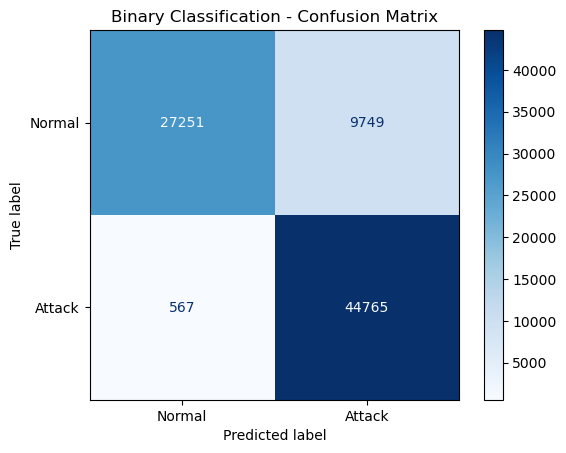

False Positive Rate (FPR): 0.2635
False Negative Rate (FNR): 0.0125


In [3]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- Preprocessing ---
# Identify categorical columns
cat_cols = ['proto', 'service', 'state', 'attack_cat']

# Encode categorical features with LabelEncoder
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    # Fit on combined unique values from train + test
    le.fit(pd.concat([train_df[col], test_df[col]]).astype(str))
    train_df[col] = le.transform(train_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))
    label_encoders[col] = le

# --- Prepare features and target for binary classification ---
drop_cols = ['id', 'label', 'attack_cat']
X_train = train_df.drop(columns=drop_cols)
y_train = train_df['label']
X_test = test_df.drop(columns=drop_cols)
y_test = test_df['label']

# --- Train XGBoost (Binary) ---
bst = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False
)
bst.fit(X_train, y_train)

# --- Predictions & Evaluation ---
preds = bst.predict(X_test)

print(classification_report(y_test, preds, target_names=['Normal', 'Attack']))

# Confusion Matrix
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Attack'])
disp.plot(cmap='Blues')
plt.title("Binary Classification - Confusion Matrix")
plt.show()

# FPR and FNR
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)
print(f"False Positive Rate (FPR): {fpr:.4f}")
print(f"False Negative Rate (FNR): {fnr:.4f}")


### 1.2 Class Attack Category Classification

# 2. Context-Aware Feature Semantics

### 2.1 Group the dataset features by meaningful cybersecurity categories




### 2.2 Attack Behavior Profiling

# 3. Misclassification and Security Error Analysis

### 3.1 Misclassification and Security Error Analysis


### 3.2 False Positive Security Interpretation

# 4. Trustworthy Security Interpretation (SOC Perspective)

### 4.1 Security-Centric Evaluation

